In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

In [20]:
print("Trades Dataset")
print(trades.head())
print(trades.info())

print("\nSentiment Dataset")
print(sentiment.head())
print(sentiment.info())

Trades Dataset
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0       

In [2]:
trades.info()
trades.isnull().sum()

sentiment.info()
sentiment.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [17]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True
)

trades['Date'] = trades['Timestamp IST'].dt.date


sentiment['date'] = pd.to_datetime(
    sentiment['date']
)

sentiment['Date'] = sentiment['date'].dt.date

In [6]:
df = pd.merge(
    trades,
    sentiment[['Date', 'classification']],
    on='Date',
    how='inner'
)

print("\nMerged Shape:")
print(df.shape)


Merged Shape:
(211218, 18)


In [9]:
print("\nTrade Count by Sentiment")
print(df['classification'].value_counts())

print("\nAverage Profit by Sentiment")
print(df.groupby('classification')['Closed PnL'].mean())

print("\nTotal Profit by Sentiment")
print(df.groupby('classification')['Closed PnL'].sum())



Trade Count by Sentiment
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

Average Profit by Sentiment
classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64

Total Profit by Sentiment
classification
Extreme Fear     7.391102e+05
Extreme Greed    2.715171e+06
Fear             3.357155e+06
Greed            2.150129e+06
Neutral          1.292921e+06
Name: Closed PnL, dtype: float64


In [10]:
df['Win'] = df['Closed PnL'] > 0

win_rate = (
    df.groupby('classification')['Win']
      .mean() * 100
)

print("\nWin Rate (%)")
print(win_rate)


Win Rate (%)
classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: Win, dtype: float64


In [12]:
print("\nAverage Trade Size (USD)")
print(
    df.groupby('classification')['Size USD']
      .mean()
)


Average Trade Size (USD)
classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64


In [13]:
top_traders = (
    df.groupby('Account')['Closed PnL']
      .sum()
      .sort_values(ascending=False)
)

print("\nTop 10 Traders")
print(top_traders.head(10))


Top 10 Traders
Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    3.605395e+05
Name: Closed PnL, dtype: float64


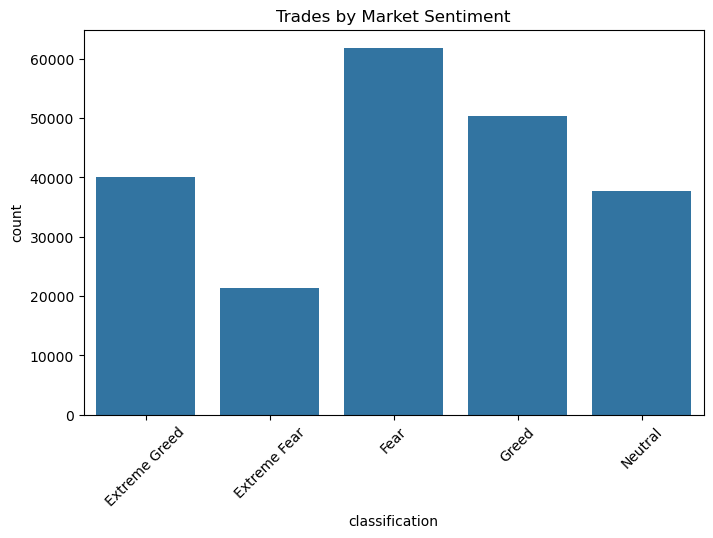

In [21]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='classification')
plt.title('Trades by Market Sentiment')
plt.xticks(rotation=45)
plt.show()

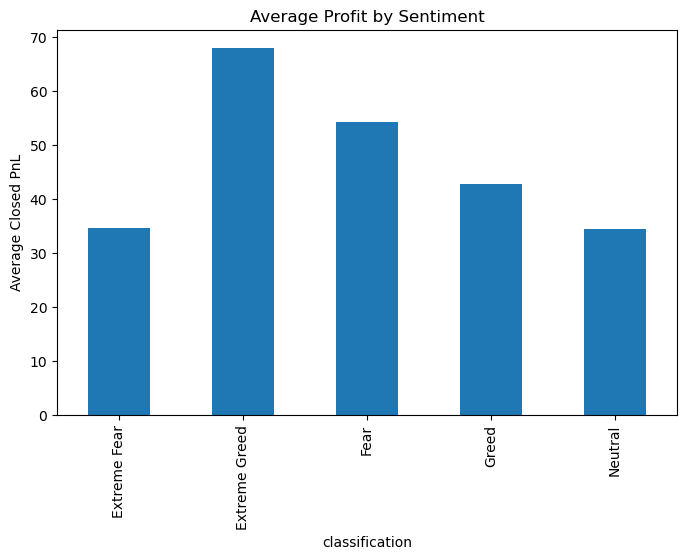

In [22]:
# Average Profit
plt.figure(figsize=(8,5))
df.groupby('classification')['Closed PnL'].mean().plot(kind='bar')
plt.title('Average Profit by Sentiment')
plt.ylabel('Average Closed PnL')
plt.show()

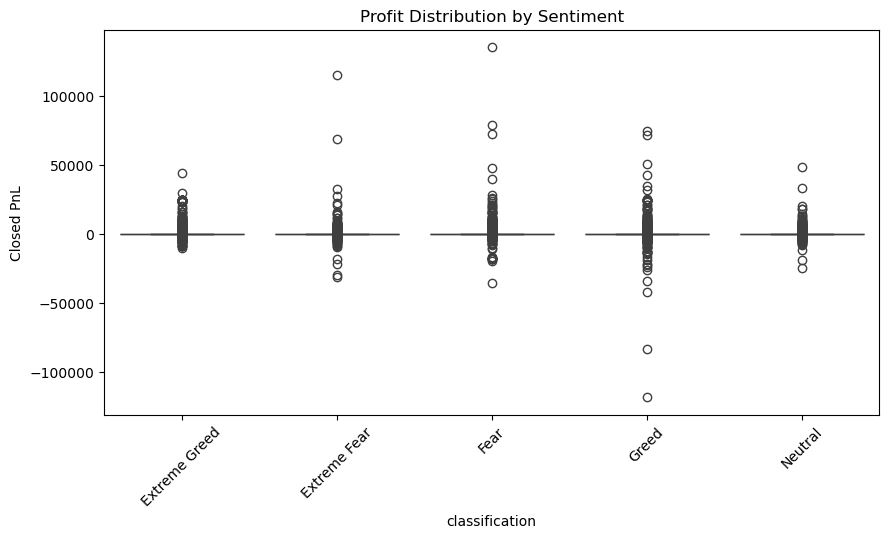

In [23]:
plt.figure(figsize=(10,5))
sns.boxplot(
    data=df,
    x='classification',
    y='Closed PnL'
)
plt.title('Profit Distribution by Sentiment')
plt.xticks(rotation=45)
plt.show()

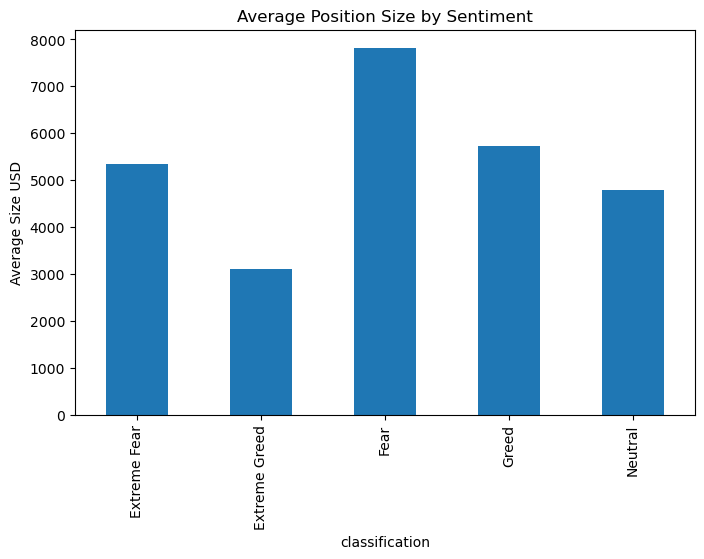

In [24]:
plt.figure(figsize=(8,5))
df.groupby('classification')['Size USD'].mean().plot(kind='bar')
plt.title('Average Position Size by Sentiment')
plt.ylabel('Average Size USD')
plt.show()


In [25]:
df.to_csv(
    "merged_trading_sentiment_data.csv",
    index=False
)

print("\nAnalysis Complete Successfully!")


Analysis Complete Successfully!


In [26]:
print(df['classification'].value_counts())

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


In [27]:
print(df.groupby('classification')['Closed PnL'].mean())

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


In [28]:
print(df.groupby('classification')['Closed PnL'].sum())

classification
Extreme Fear     7.391102e+05
Extreme Greed    2.715171e+06
Fear             3.357155e+06
Greed            2.150129e+06
Neutral          1.292921e+06
Name: Closed PnL, dtype: float64
